# Idea

### Goal: 
- The idea here is to try to inspect the fitness formula and to find a valid alternative to this formula to use in our model and from wich gain information

### Workflow:
1. Separate the process and the Sequencing aspect with code: generate some data for these 3 class:weak strong and decoy. work with absolute concentration and set the rule that (on average) the variation in the drug condition would be 25% less for strong, 5%less for decoy and 0%less for weak. Compute the numbers, compute the fitness and compare that the fitness itself doesn't match the realhappening in the world.
2. Understand that we are facing a Compositional Problem
3. Inspect proposed solution of this problem (find a size factor as sum(reads_condition / sum(reads_control) or median(reads_condition/reads_control) one for all the condition or different size factor for each condition??????))
4. try different methods and test them in the toy example proposed before. 
5. apply this to our data -->  

        a) redo some exploratory analysis 
        b) find if we can use these data to fit

In [ ]:
# Standard libraries used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns


# --------------------------------------------------------------------------
# PARAMETER — PATH_DATASET
# --------------------------------------------------------------------------

PATH_DATASET = r"C:\Users\marco\Desktop\Tesi\.LabWork\Data\Data from Suzanne\fitness_calc_PB_H3B.xlsx"

# We load the raw file with no changes.
# data_raw will never be modified — it stays as the original reference.
data_raw = pd.read_excel(PATH_DATASET)


# --------------------------------------------------------------------------
# Data Filtering
# --------------------------------------------------------------------------

MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data_raw["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

data_filtered = data_raw[mask_ok].copy().reset_index(drop=True)

max_decoy_stratified = data_filtered[data_filtered['DECOY'] == 'Decoy 1']
no_decoy_stratified = data_filtered[data_filtered['DECOY'] == 'Decoy 7']

# --------------------------------------------------------------------------
# CONSTANT definition
# --------------------------------------------------------------------------
DRUG_CONCENTRATIONS = [1e-11, 1e-10, 2e-10, 4e-10, 1e-09]

In [35]:
# cols = ['seq_id','Input_counts','output_Ctrl','output_PB1', 'output_PB2', 'output_PB4', 'output_PB8']
df = data_filtered.copy()

## Compute the size factor for each condition

In [54]:
# median rateo reads_condition / reads_input

conditions = ['output_Ctrl','output_PB1', 'output_PB2', 'output_PB4', 'output_PB8']
names = [c.split('_')[1] for c in conditions]
size_factor_medians = [np.median(df[c]/ df['Input_counts']) for c in conditions]
for i in range(len(conditions)):
    df['normalized_'+ names[i]] = df[conditions[i]] / size_factor_medians[i]
for i in range(len(conditions)):
    print(f"Condition: {conditions[i]} Size Factor: {float(size_factor_medians[i]):.3}")

Condition: output_Ctrl Size Factor: 0.0785
Condition: output_PB1 Size Factor: 0.105
Condition: output_PB2 Size Factor: 0.164
Condition: output_PB4 Size Factor: 0.194
Condition: output_PB8 Size Factor: 0.211


## Check the size factor variation

In [50]:
reference = size_factor_medians[0]
pct_variations = ((size_factor_medians - reference) / reference) * 100
for i in range(len(conditions) -1):
    print(f"Pct variation for condition {conditions[i +1]}: {float(pct_variations[i]):.7} %")

Pct variation for condition output_PB1: 0.0 %
Pct variation for condition output_PB2: 33.46026 %
Pct variation for condition output_PB4: 108.6433 %
Pct variation for condition output_PB8: 147.4557 %


# ATTENCTION PLEASE!!!!

The size factor computed are really different between them (we have also 147% of variation between control and max_drug).

This imply that we cannot compare the condition between them but only with the initial condition.

We could have used a global factor to compare between them but given that we're interested in the behaviour related to the input library we'll proceed with this normalization

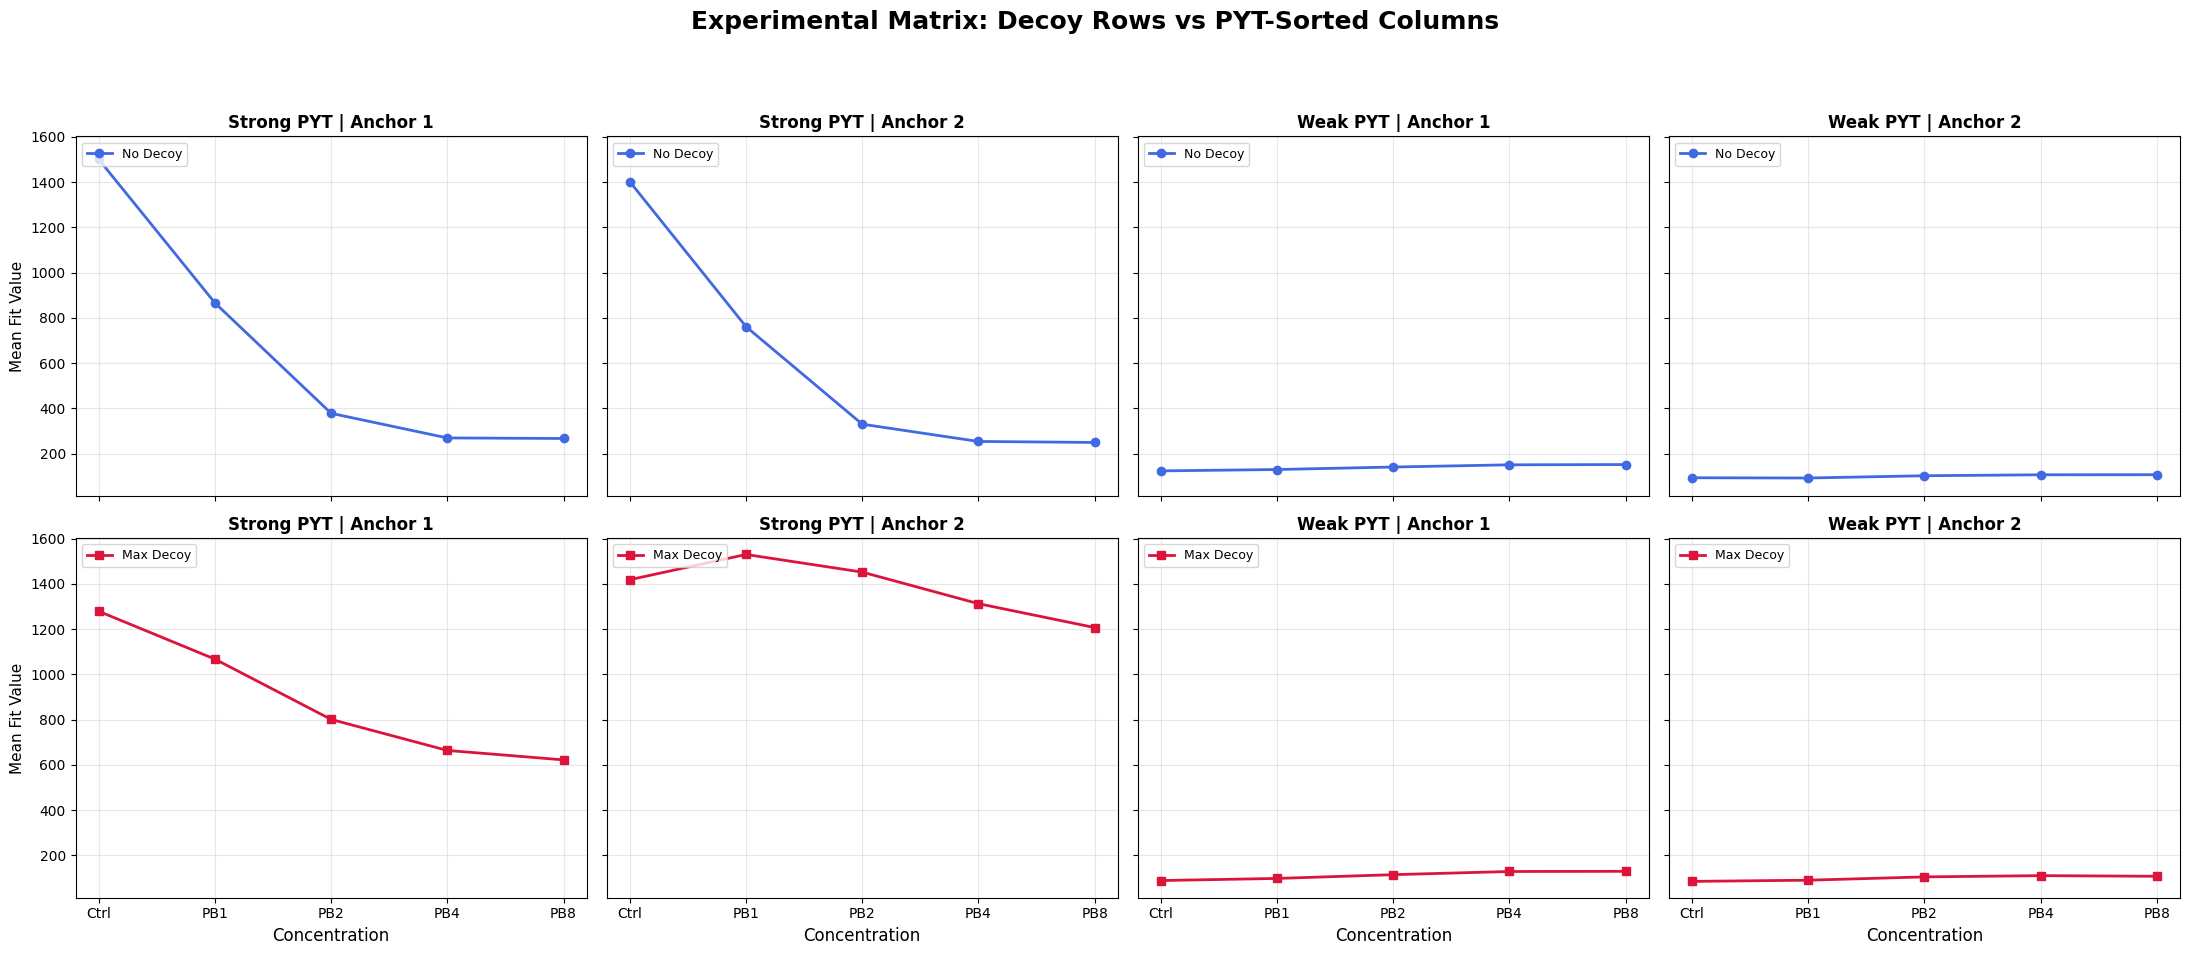

In [38]:
# Seleziona solo le colonne che contengono la parola 'normalized'

def get_trend_data(df):
    pb_cols = [col for col in df.columns if 'normalized_' in col]
    target_columns = sorted(pb_cols)
    
    # Calculate means and extract labels
    mean_values = df[target_columns].mean()
    x_labels = [col.split('_')[-1] for col in target_columns]
    return x_labels, mean_values

# Ordered lists to explicitly control column distribution
pyt_types = ['Strong', 'Weak']
anchors = [1, 2]
filter_cols = ['ANCHOR', 'DECOY', 'PYT', 'normalized_Ctrl', 'normalized_PB1', 'normalized_PB2', 'normalized_PB4', 'normalized_PB8']

# Setup the 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
fig.suptitle('Experimental Matrix: Decoy Rows vs PYT-Sorted Columns', fontsize=18, fontweight='bold')

# Loop through Decoy targets for rows
for row_idx, decoy_target in enumerate(['Decoy 7', 'Decoy 1']):
    col_idx = 0
    
    # Nested loops ordered by PYT first, then ANCHOR to match your requested layout
    for pyt_val in pyt_types:
        for anchor_val in anchors:
            
            ax = axes[row_idx, col_idx]
            
            # Filter the main dataframe for this specific grid cell
            df_sub = df[filter_cols].copy()
            df_sub = df_sub[
                (df_sub['ANCHOR'] == anchor_val) & 
                (df_sub['PYT'] == pyt_val) & 
                (df_sub['DECOY'] == decoy_target)
            ]
            
            # Visual configuration based on the row condition
            if decoy_target == 'Decoy 7':
                plot_color = 'royalblue'
                plot_marker = 'o'
                decoy_label = 'No Decoy'
            else:
                plot_color = 'crimson'
                plot_marker = 's'
                decoy_label = 'Max Decoy'
                
            # Plot data if the subset contains records
            if not df_sub.empty:
                x, y = get_trend_data(df_sub)
                ax.plot(x, y, marker=plot_marker, color=plot_color, linewidth=2, label=f'{decoy_label}')
                ax.grid(True, alpha=0.3)
                ax.legend(loc='upper left', fontsize=9)
            
            # Subplot title focusing clearly on PYT and ANCHOR
            ax.set_title(f'{pyt_val} PYT | Anchor {anchor_val}', fontsize=12, fontweight='semibold')
            
            # Add Y-axis label only to the first column to keep it clean
            if col_idx == 0:
                ax.set_ylabel('Mean Fit Value', fontsize=11)
                
            col_idx += 1

# Add X-axis label only to the bottom row subplots
for ax in axes[-1, :]:
    ax.set_xlabel('Concentration', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()